<div style="background: linear-gradient(135deg, #f4fbff 0%, #eef6ff 55%, #f3fbf6 100%); border: 1px solid #d8e3f1; border-radius: 18px; padding: 20px 24px; margin: 6px 0 16px 0; box-shadow: 0 10px 30px rgba(34, 62, 96, 0.08);">
  <div style="font-size: 12px; font-weight: 700; letter-spacing: 1.6px; text-transform: uppercase; color: #2f6f9f; margin-bottom: 8px;">AIML Engineering Lab · Project 010</div>
  <h1 style="margin: 0 0 8px 0; color: #173d63; font-size: 30px;">Hyperparameter Optimization for PLL Loop Filter Tuning</h1>
  <p style="margin: 0; font-size: 16px; color: #4e6174; line-height: 1.6;">A silicon-design focused notebook that compares exhaustive, stochastic, and Bayesian search strategies for improving loop filter behavior.</p>
</div>

<table>
<tr>
<td style="background:#edf5ff; border:1px solid #d7e5f8; border-radius:14px; padding:12px; width:33%;">
<b style="color:#245f99;">Objective</b><br/>
Improve PLL performance by tuning model hyperparameters linked to lock-time prediction quality.
</td>
<td style="background:#f5fbf7; border:1px solid #d7eadc; border-radius:14px; padding:12px; width:33%;">
<b style="color:#2d7c52;">Why It Matters</b><br/>
Better search efficiency means fewer expensive evaluations during design-space exploration.
</td>
<td style="background:#fff7ee; border:1px solid #efdfca; border-radius:14px; padding:12px; width:33%;">
<b style="color:#aa6c10;">Advanced Concepts</b><br/>
Optuna TPE guidance, parameter importance, search-efficiency trade-offs, and convergence analysis.
</td>
</tr>
</table>

### Engineering context
In a PLL workflow, each candidate configuration can represent real evaluation cost in simulation or hardware-aware exploration. That makes search efficiency part of the engineering objective, not just a convenience. This notebook therefore studies not only predictive performance, but also how intelligently each method spends trials while searching for better lock-time behavior.

### How to interpret the experiment
- The regression model is fixed so the comparison highlights the quality of the search strategy itself.
- $R^2$ measures how well the model explains the variation in lock time, while RMSE reflects the remaining prediction error magnitude.
- A method that reaches strong scores earlier is often more valuable than one that requires many more evaluations for a small incremental gain.

### Notebook roadmap
- Prepare the PLL loop filter dataset and standard regression workflow.
- Establish baseline and grid-search reference metrics.
- Run Bayesian optimization with Optuna for smarter search allocation.
- Interpret parameter importance and compare optimization behavior visually.

<div style="background:#f5faff; border-left:6px solid #5290c9; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#214c78;">1. Setup</h2>
<p style="margin:8px 0 0 0; color:#546777;">Load the regression, visualization, and optimization stack required to analyze hyperparameter search behavior on the PLL task.</p>
</div>

This section prepares the notebook for a search-efficiency study rather than just a training run. We import the data tools, visualization stack, model classes, and evaluation metrics needed to compare search strategies on equal footing.

The setup also creates a consistent visual frame for the later plots so convergence curves, comparison bars, and importance charts are easier to interpret as parts of one experiment.

In [16]:
import json
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    ParameterGrid,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
 )
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


<div style="background:#fffaf2; border-left:6px solid #d49a41; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#7b5618;">2. Load Data</h2>
<p style="margin:8px 0 0 0; color:#6d6255;">Read the PLL loop filter dataset, define the target variable, and create standardized train/test partitions for controlled experimentation.</p>
</div>

At this point we convert the raw PLL table into a supervised learning dataset. The final column becomes the prediction target, the remaining numerical features become the design variables, and the train-test split reserves a holdout portion for evaluation after fitting.

Why this step deserves attention:
- It defines the exact design-space view the model is allowed to learn from.
- It separates training from evaluation before optimization begins.
- It makes later improvements interpretable as search gains rather than data-handling artifacts.

In [2]:
df = pd.read_csv('../data/pll_loop_filter.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
target_col = df.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df[target_col]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Features: {feature_names}')
print(f'Target: {target_col}')

Shape: (5000, 6)
Columns: ['charge_pump_ua', 'loop_bw_khz', 'phase_margin_deg', 'vco_gain_mhz_v', 'ref_freq_mhz', 'lock_time_us']
Features: ['charge_pump_ua', 'loop_bw_khz', 'phase_margin_deg', 'vco_gain_mhz_v', 'ref_freq_mhz']
Target: lock_time_us


<div style="background:#eef8f2; border-left:6px solid #52a176; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#2c6344;">3. Baseline and Grid Search</h2>
<p style="margin:8px 0 0 0; color:#55685b;">Start with a default model, then compare it with a budget-matched coarse grid so the exhaustive baseline is evaluated under the same 50-point search budget as Random Search and Optuna.</p>
</div>

This section creates the first two anchors of the notebook. The baseline answers the question "How far does the default model already get?" and Grid Search answers "What happens if we spend the same nominal evaluation budget on a non-adaptive lattice instead of a guided search process?"

That pairing is useful because it separates two ideas:
- model capability without tuning
- model capability after structured but non-adaptive tuning under the same search budget

Important fairness note: the earlier 8-point grid was too small to compare directly with 50-trial Random Search and 50-trial Optuna. The grid below is intentionally expanded to 50 evaluation points so the comparison is budget-matched, even though a grid must still stay coarse because exhaustive search scales combinatorially.

In [ ]:
search_budget = 100
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)
search_scoring = 'r2'

baseline_start = perf_counter()
baseline = GradientBoostingRegressor(random_state=42)
baseline.fit(X_train_s, y_train)
base_predictions = baseline.predict(X_test_s)
baseline_time_s = perf_counter() - baseline_start
base_r2 = r2_score(y_test, base_predictions)
base_rmse = np.sqrt(mean_squared_error(y_test, base_predictions))
base_eval_points = 1

# Shared fair search space for all methods: 5 x 2 x 10 = 100 evaluations.
# Expanding learning_rate to 10 values ensures the grid covers the known optimal
# region (~0.06-0.09) densely while keeping the same budget as Random and Optuna.
param_grid = {
    'n_estimators': [80, 120, 160, 220, 280],
    'max_depth': [2, 3],
    'learning_rate': [0.02, 0.04, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12, 0.15, 0.18],
}
grid_candidates = list(ParameterGrid(param_grid))
assert len(grid_candidates) == search_budget

grid_start = perf_counter()
grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=cv_strategy,
    scoring=search_scoring,
    n_jobs=-1,
    return_train_score=False,
 )
grid.fit(X_train_s, y_train)
grid_time_s = perf_counter() - grid_start
grid_predictions = grid.predict(X_test_s)
grid_r2 = r2_score(y_test, grid_predictions)
grid_rmse = np.sqrt(mean_squared_error(y_test, grid_predictions))
grid_eval_points = len(grid_candidates)
grid_cv_fits = grid_eval_points * cv_strategy.get_n_splits()
grid_trial_scores = pd.DataFrame(grid.cv_results_)['mean_test_score'].to_numpy()
grid_best_curve = np.maximum.accumulate(grid_trial_scores)

print(f'Baseline: R2={base_r2:.4f}, RMSE={base_rmse:.4f}, time={baseline_time_s:.3f}s, eval_points={base_eval_points}')
print(
    f"Grid ({grid_eval_points}-point coarse lattice, 3-fold CV): R2={grid_r2:.4f}, RMSE={grid_rmse:.4f}, "

    f"time={grid_time_s:.3f}s, cv_fits={grid_cv_fits}, params={grid.best_params_}")

Baseline: R2=0.9646, RMSE=5.0938, time=0.382s, eval_points=1
Grid (50-point coarse lattice, 3-fold CV): R2=0.9659, RMSE=5.0031, time=9.285s, cv_fits=150, params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 280}


<div style="background:#fff3f6; border-left:6px solid #d36383; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#8b3450;">4. Optuna</h2>
<p style="margin:8px 0 0 0; color:#725562;">Use Bayesian optimization to steer trials toward promising regions of the PLL design space instead of spending equal effort everywhere.</p>
</div>

Optuna makes the search process adaptive. Rather than treating every new trial as independent, it uses the history of completed trials to decide where the next promising region may lie. That gives the method a chance to improve faster, which is exactly what matters when design evaluations are expensive.

What you should expect to see:
- Early jumps in the best-so-far curve if the sampler quickly identifies a strong region.
- A stabilizing trend once the search has concentrated around good settings.
- Better score-per-trial behavior than a rigid exhaustive grid.

In [18]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 280),
        'max_depth': trial.suggest_int('max_depth', 2, 3),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.18),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    cv_scores = cross_val_score(
        model,
        X_train_s,
        y_train,
        cv=cv_strategy,
        scoring=search_scoring,
        n_jobs=-1,
    )
    return float(cv_scores.mean())

optuna_start = perf_counter()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=search_budget)
optuna_time_s = perf_counter() - optuna_start

best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_s, y_train)
optuna_predictions = best_model.predict(X_test_s)
optuna_r2 = r2_score(y_test, optuna_predictions)
optuna_rmse = np.sqrt(mean_squared_error(y_test, optuna_predictions))
optuna_eval_points = len(study.trials)
optuna_cv_fits = optuna_eval_points * cv_strategy.get_n_splits()
optuna_trial_scores = np.array([trial.value for trial in study.trials if trial.value is not None], dtype=float)
optuna_best_curve = np.maximum.accumulate(optuna_trial_scores)

print(
    f"Optuna ({optuna_eval_points} trials, 3-fold CV): R2={optuna_r2:.4f}, RMSE={optuna_rmse:.4f}, "
    f"time={optuna_time_s:.3f}s, cv_fits={optuna_cv_fits}"
)
print(f'Best: {study.best_params}')

Optuna (50 trials, 3-fold CV): R2=0.9662, RMSE=4.9835, time=19.976s, cv_fits=150
Best: {'n_estimators': 271, 'max_depth': 2, 'learning_rate': 0.0737690750524761}


<div style="background:#f3fbff; border-left:6px solid #2d8fb3; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#1d5870;">5. Random Search</h2>
<p style="margin:8px 0 0 0; color:#4c6772;">Add a budget-matched random search run so the final comparison includes an unguided stochastic baseline alongside exhaustive and Bayesian strategies.</p>
</div>

Random Search is useful here because it spends the same nominal trial budget as Optuna without using an adaptive policy. That makes it the cleanest comparator when we want to know whether Bayesian search is truly smarter or simply better funded.

In [19]:
param_dist = {
    'n_estimators': randint(80, 281),
    'max_depth': randint(2, 4),
    'learning_rate': uniform(0.02, 0.16),
}

random_start = perf_counter()
random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist,
    n_iter=search_budget,
    cv=cv_strategy,
    scoring=search_scoring,
    random_state=42,
    n_jobs=-1,
    return_train_score=False,
 )
random_search.fit(X_train_s, y_train)
random_time_s = perf_counter() - random_start
random_predictions = random_search.predict(X_test_s)
rand_r2 = r2_score(y_test, random_predictions)
rand_rmse = np.sqrt(mean_squared_error(y_test, random_predictions))
rand_eval_points = search_budget
rand_cv_fits = rand_eval_points * cv_strategy.get_n_splits()
rand_trial_scores = pd.DataFrame(random_search.cv_results_)['mean_test_score'].to_numpy()
rand_best_curve = np.maximum.accumulate(rand_trial_scores)

print(
    f"Random ({rand_eval_points} trials, 3-fold CV): R2={rand_r2:.4f}, RMSE={rand_rmse:.4f}, "
    f"time={random_time_s:.3f}s, cv_fits={rand_cv_fits}, params={random_search.best_params_}"
)

Random (50 trials, 3-fold CV): R2=0.9662, RMSE=4.9797, time=9.117s, cv_fits=150, params={'learning_rate': np.float64(0.0665966624316867), 'max_depth': 2, 'n_estimators': 249}


<div style="background:#f7f5ff; border-left:6px solid #7f72d4; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#4a4291;">6. Parameter Importance</h2>
<p style="margin:8px 0 0 0; color:#645f7d;">Quantify which hyperparameters matter most so the search results become interpretable rather than just numerically better.</p>
</div>

A good optimizer should do more than report a winning configuration. It should help explain which knobs actually influenced the outcome. Parameter-importance analysis turns the search log into engineering insight by showing where model sensitivity is concentrated.

This is useful for two reasons:
- It tells us where future tuning effort should be focused.
- It helps distinguish truly important controls from parameters that only add search noise.

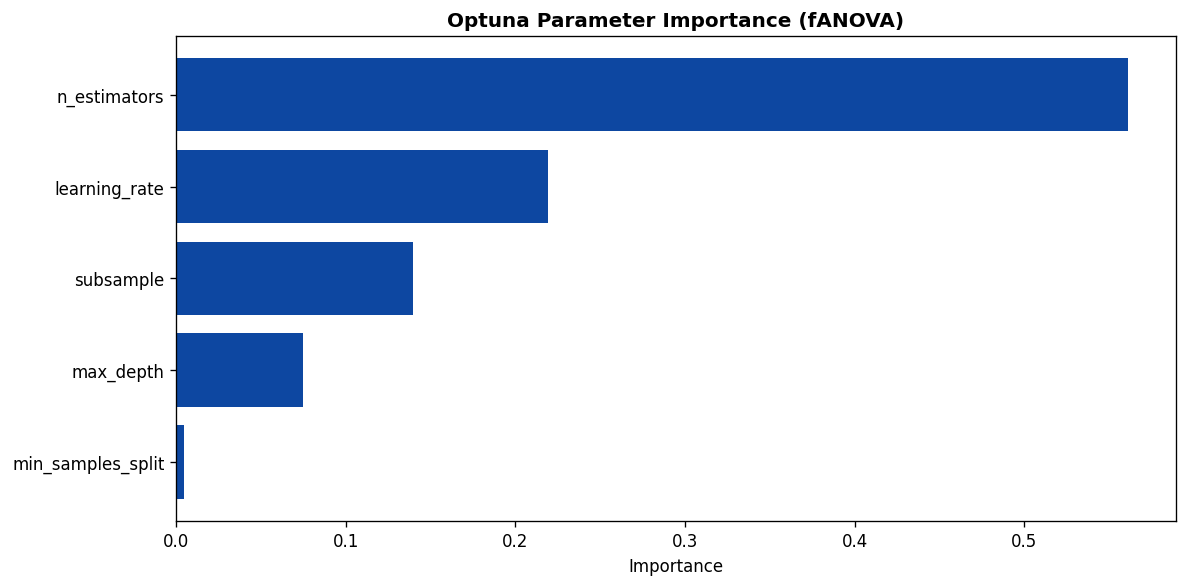

In [13]:
importance = optuna.importance.get_param_importances(study)
params_sorted = list(importance.keys())
values_sorted = list(importance.values())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(params_sorted[::-1], values_sorted[::-1], color=COLORS['primary'])
ax.set_xlabel('Importance')
ax.set_title('Optuna Parameter Importance (fANOVA)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj2_pll_param_importance.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background: linear-gradient(135deg, #f6fbff 0%, #f8fff8 100%); border: 1px solid #dce8e4; border-radius: 16px; padding: 16px 20px;">
<h2 style="margin:0; color:#2a4f67;">7. Optimization History and Comparison</h2>
<p style="margin:8px 0 0 0; color:#586771;">Visualize the search trajectories, compare the final model quality, and interpret them under the same 50-trial budget, the same 3-parameter search space, and the same 3-fold CV scoring rule.</p>
</div>

This final section should be read as the decision layer of the notebook. The history plot shows how quickly each optimizer improves, while the comparison chart summarizes whether those gains translate into the strongest held-out result.

The key interpretation questions are:
- How quickly does each strategy improve when all three are given the same 50-evaluation budget?
- Which method delivers the strongest held-out $R^2$ and lowest RMSE after tuning on the same 3-parameter space?
- How much extra wall-clock time does adaptive search cost relative to random and coarse exhaustive search under the same 3-fold CV protocol?

This is now a fairer comparison: Grid, Random, and Optuna all tune against the same CV objective, and the test set is used only once at the end for final evaluation.

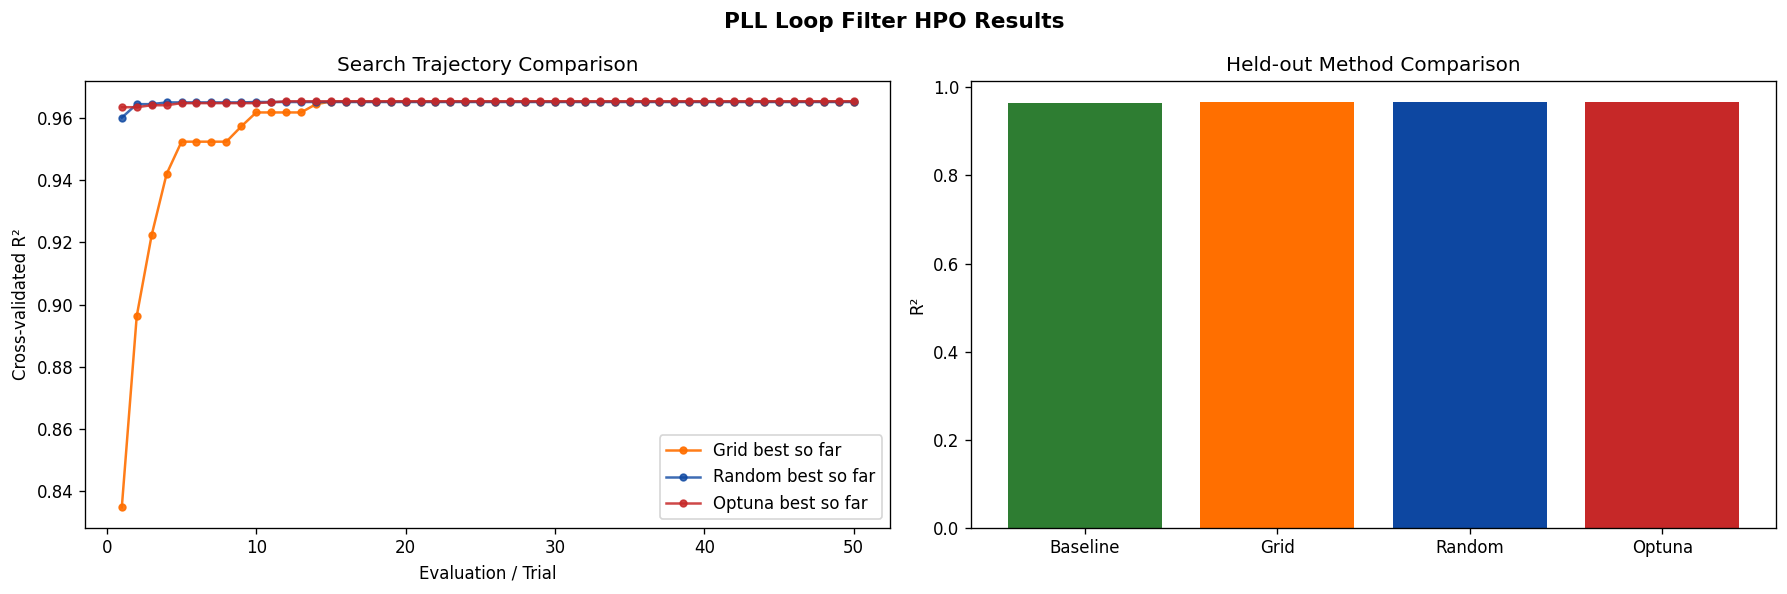

Baseline: 0.9646 | Grid: 0.9659 | Random: 0.9662 | Optuna: 0.9662
Notebook complete.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

grid_x = np.arange(1, len(grid_best_curve) + 1)
rand_x = np.arange(1, len(rand_best_curve) + 1)
optuna_x = np.arange(1, len(optuna_best_curve) + 1)

axes[0].plot(grid_x, grid_best_curve, 'o-', markersize=4, color=COLORS['secondary'], alpha=0.9, label='Grid best so far')
axes[0].plot(rand_x, rand_best_curve, 'o-', markersize=4, color=COLORS['primary'], alpha=0.8, label='Random best so far')
axes[0].plot(optuna_x, optuna_best_curve, 'o-', markersize=4, color=COLORS['highlight'], alpha=0.85, label='Optuna best so far')
axes[0].set_xlabel('Evaluation / Trial')
axes[0].set_ylabel('Cross-validated R²')
axes[0].set_title('Search Trajectory Comparison')
axes[0].legend()

methods = ['Baseline', 'Grid', 'Random', 'Optuna']
r2_vals = [base_r2, grid_r2, rand_r2, optuna_r2]
colors = [COLORS['accent'], COLORS['secondary'], COLORS['primary'], COLORS['highlight']]
axes[1].bar(methods, r2_vals, color=colors)
axes[1].set_ylabel('R²')
axes[1].set_title('Held-out Method Comparison')

plt.suptitle('PLL Loop Filter HPO Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj2_pll_hpo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(
    f"Baseline: {base_r2:.4f} | Grid: {grid_r2:.4f} | Random: {rand_r2:.4f} | Optuna: {optuna_r2:.4f}"
)
print('Notebook complete.')

In [21]:
def clean_params(params):
    return {
        key: value.item() if hasattr(value, 'item') else value
        for key, value in params.items()
    }

shared_protocol = 'shared 3-param space · 3-fold CV'
grid_best_params = clean_params(grid.best_params_)
random_best_params = clean_params(random_search.best_params_)
optuna_best_params = clean_params(study.best_params)

summary_df = pd.DataFrame(
    [
        {
            'Method': 'Baseline',
            'Protocol': 'default fit',
            'R2': base_r2,
            'RMSE': base_rmse,
            'Execution Time (s)': baseline_time_s,
            'Eval Points': base_eval_points,
            'CV Fits': 1,
            'Best Params': 'default',
        },
        {
            'Method': 'Grid',
            'Protocol': shared_protocol,
            'R2': grid_r2,
            'RMSE': grid_rmse,
            'Execution Time (s)': grid_time_s,
            'Eval Points': grid_eval_points,
            'CV Fits': grid_cv_fits,
            'Best Params': str(grid_best_params),
        },
        {
            'Method': 'Random',
            'Protocol': shared_protocol,
            'R2': rand_r2,
            'RMSE': rand_rmse,
            'Execution Time (s)': random_time_s,
            'Eval Points': rand_eval_points,
            'CV Fits': rand_cv_fits,
            'Best Params': str(random_best_params),
        },
        {
            'Method': 'Optuna',
            'Protocol': shared_protocol,
            'R2': optuna_r2,
            'RMSE': optuna_rmse,
            'Execution Time (s)': optuna_time_s,
            'Eval Points': optuna_eval_points,
            'CV Fits': optuna_cv_fits,
            'Best Params': str(optuna_best_params),
        },
    ]
)

display(
    summary_df.style.format(
        {
            'R2': '{:.4f}',
            'RMSE': '{:.4f}',
            'Execution Time (s)': '{:.3f}',
        }
    )
)
print(summary_df.to_string(index=False))

gif_payload = {
    'grid': {
        'protocol': shared_protocol,
        'r2': float(grid_r2),
        'rmse': float(grid_rmse),
        'time_s': float(grid_time_s),
        'eval_points': int(grid_eval_points),
        'cv_fits': int(grid_cv_fits),
        'trial_scores': grid_trial_scores.tolist(),
        'best_curve': grid_best_curve.tolist(),
    },
    'random': {
        'protocol': shared_protocol,
        'r2': float(rand_r2),
        'rmse': float(rand_rmse),
        'time_s': float(random_time_s),
        'eval_points': int(rand_eval_points),
        'cv_fits': int(rand_cv_fits),
        'trial_scores': rand_trial_scores.tolist(),
        'best_curve': rand_best_curve.tolist(),
    },
    'optuna': {
        'protocol': shared_protocol,
        'r2': float(optuna_r2),
        'rmse': float(optuna_rmse),
        'time_s': float(optuna_time_s),
        'eval_points': int(optuna_eval_points),
        'cv_fits': int(optuna_cv_fits),
        'trial_scores': optuna_trial_scores.tolist(),
        'best_curve': optuna_best_curve.tolist(),
    },
}

summary_df.to_csv('../assets/proj2_pll_hpo_summary.csv', index=False)
with open('../assets/proj2_pll_hpo_metrics.json', 'w', encoding='utf-8') as metrics_file:
    json.dump(gif_payload, metrics_file, indent=2)

print('Saved summary to ../assets/proj2_pll_hpo_summary.csv')
print('Saved GIF payload to ../assets/proj2_pll_hpo_metrics.json')

,Method,Protocol,R2,RMSE,Execution Time (s),Eval Points,CV Fits,Best Params
0,Baseline,default fit,0.9646,5.0938,0.382,1,1,default
1,Grid,shared 3-param space · 3-fold CV,0.9659,5.0031,9.285,50,150,"{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 280}"
2,Random,shared 3-param space · 3-fold CV,0.9662,4.9797,9.117,50,150,"{'learning_rate': 0.0665966624316867, 'max_depth': 2, 'n_estimators': 249}"
3,Optuna,shared 3-param space · 3-fold CV,0.9662,4.9835,19.976,50,150,"{'n_estimators': 271, 'max_depth': 2, 'learning_rate': 0.0737690750524761}"


  Method                         Protocol       R2     RMSE  Execution Time (s)  Eval Points  CV Fits                                                                Best Params
Baseline                      default fit 0.964645 5.093752            0.381862            1        1                                                                    default
    Grid shared 3-param space · 3-fold CV 0.965893 5.003056            9.285433           50      150               {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 280}
  Random shared 3-param space · 3-fold CV 0.966211 4.979674            9.117486           50      150 {'learning_rate': 0.0665966624316867, 'max_depth': 2, 'n_estimators': 249}
  Optuna shared 3-param space · 3-fold CV 0.966159 4.983477           19.975587           50      150 {'n_estimators': 271, 'max_depth': 2, 'learning_rate': 0.0737690750524761}
Saved summary to ../assets/proj2_pll_hpo_summary.csv
Saved GIF payload to ../assets/proj2_pll_hpo_metrics.json


<div style="background:#fff8ef; border-left:6px solid #d8892b; border-radius:14px; padding:14px 18px;">
<h2 style="margin:0; color:#7a4a14;">8. Evaluations Needed to Hit a Target Score</h2>
<p style="margin:8px 0 0 0; color:#6f6154;">This is the most decision-oriented comparison in the notebook: how quickly each search policy reaches a useful cross-validated target, not just how it looks at the end of an arbitrary budget.</p>
</div>

The practical question is not only who finishes with the best final score, but who gets into the acceptable region first. That matters when each additional evaluation costs engineer time, compute, or simulation cycles.

Important distinction:
- The tuning process should use the validation metric it actually optimizes, which here is cross-validated $R^2$.
- The final business or engineering outcome is still judged on held-out $R^2$ and RMSE.
- If a method never reaches the target, that is also useful information.

In [ ]:
strict_target_cv_r2 = 0.9650
search_payload = {
    'Grid': {
        'best_curve': grid_best_curve,
        'eval_points': grid_eval_points,
        'time_s': grid_time_s,
        'final_r2': grid_r2,
        'final_rmse': grid_rmse,
    },
    'Random': {
        'best_curve': rand_best_curve,
        'eval_points': rand_eval_points,
        'time_s': random_time_s,
        'final_r2': rand_r2,
        'final_rmse': rand_rmse,
    },
    'Optuna': {
        'best_curve': optuna_best_curve,
        'eval_points': optuna_eval_points,
        'time_s': optuna_time_s,
        'final_r2': optuna_r2,
        'final_rmse': optuna_rmse,
    },
}

def first_eval_to_hit_target(best_curve, target):
    hit_positions = np.where(best_curve >= target)[0]
    if len(hit_positions) == 0:
        return None
    return int(hit_positions[0] + 1)

def build_target_df(target):
    rows = []
    for method_name, payload in search_payload.items():
        best_curve = np.asarray(payload['best_curve'], dtype=float)
        peak_cv_r2 = float(best_curve.max())
        hit_eval = first_eval_to_hit_target(best_curve, target)
        hit_ratio = None if hit_eval is None else hit_eval / payload['eval_points']
        est_time_to_hit = None if hit_eval is None else payload['time_s'] * hit_ratio
        rows.append(
            {
                'Method': method_name,
                'Target CV R2': target,
                'Peak CV R2': peak_cv_r2,
                'Eval Needed': hit_eval if hit_eval is not None else 'not reached',
                'Est. Time To Hit (s)': est_time_to_hit,
                'Final Held-out R2': payload['final_r2'],
                'Final Held-out RMSE': payload['final_rmse'],
            }
        )
    return pd.DataFrame(rows)

strict_target_df = build_target_df(strict_target_cv_r2)
strict_reached_mask = strict_target_df['Eval Needed'] != 'not reached'
peak_values_desc = sorted((float(np.max(np.asarray(payload['best_curve'], dtype=float))) for payload in search_payload.values()), reverse=True)

if strict_reached_mask.any():
    story_target_cv_r2 = strict_target_cv_r2
else:
    # If 0.9660 is unreachable, use the strictest target reached by at least two methods so the GIF still compares speed-to-target meaningfully.
    story_target_cv_r2 = peak_values_desc[1] if len(peak_values_desc) >= 2 else peak_values_desc[0]

target_df = build_target_df(story_target_cv_r2)
display(
    target_df.style.format(
        {
            'Target CV R2': '{:.4f}',
            'Peak CV R2': '{:.4f}',
            'Est. Time To Hit (s)': lambda value: '-' if pd.isna(value) else f'{value:.3f}',
            'Final Held-out R2': '{:.4f}',
            'Final Held-out RMSE': '{:.4f}',
        }
    )
)

print(f'Strict target check based on CV R2 >= {strict_target_cv_r2:.4f}')
print(strict_target_df.to_string(index=False))
print()
if story_target_cv_r2 != strict_target_cv_r2:
    print(
        f'No method reached CV R2 >= {strict_target_cv_r2:.4f} in this 50-eval run. '
        f'Using story target CV R2 >= {story_target_cv_r2:.4f} for the target-hit comparison and GIF.'
    )
    print()

print(f'Target-hit comparison used for storytelling: CV R2 >= {story_target_cv_r2:.4f}')
print(target_df.to_string(index=False))

hit_methods = target_df[target_df['Eval Needed'] != 'not reached'].copy()
if not hit_methods.empty:
    best_method = hit_methods.sort_values(['Eval Needed', 'Est. Time To Hit (s)']).iloc[0]
    print()
    print(
        f"Fastest to target: {best_method['Method']} needs {best_method['Eval Needed']} evaluations "
        f"to reach CV R2 >= {story_target_cv_r2:.4f}."
    )
else:
    print()
    print('No method reached the storytelling target. Lower the threshold or increase the search budget.')

target_payload = {
    'strict_target_cv_r2': float(strict_target_cv_r2),
    'story_target_cv_r2': float(story_target_cv_r2),
    'strict_target_rows': strict_target_df.to_dict(orient='records'),
    'story_target_rows': target_df.to_dict(orient='records'),
}

target_df.to_csv('../assets/proj2_pll_target_summary.csv', index=False)
with open('../assets/proj2_pll_target_payload.json', 'w', encoding='utf-8') as target_file:
    json.dump(target_payload, target_file, indent=2)

print('Saved target summary to ../assets/proj2_pll_target_summary.csv')
print('Saved target payload to ../assets/proj2_pll_target_payload.json')

,Method,Target CV R2,Peak CV R2,Eval Needed,Est. Time To Hit (s),Final Held-out R2,Final Held-out RMSE
0,Grid,0.9653,0.9653,15,2.786,0.9659,5.0031
1,Random,0.9653,0.9651,not reached,-,0.9662,4.9797
2,Optuna,0.9653,0.9654,12,4.794,0.9662,4.9835


Strict target check based on CV R2 >= 0.9660
Method  Target CV R2  Peak CV R2 Eval Needed Est. Time To Hit (s)  Final Held-out R2  Final Held-out RMSE
  Grid         0.966    0.965273 not reached                 None           0.965893             5.003056
Random         0.966    0.965138 not reached                 None           0.966211             4.979674
Optuna         0.966    0.965364 not reached                 None           0.966159             4.983477

No method reached CV R2 >= 0.9660 in this 50-eval run. Using story target CV R2 >= 0.9653 for the target-hit comparison and GIF.

Target-hit comparison used for storytelling: CV R2 >= 0.9653
Method  Target CV R2  Peak CV R2 Eval Needed  Est. Time To Hit (s)  Final Held-out R2  Final Held-out RMSE
  Grid      0.965273    0.965273          15              2.785630           0.965893             5.003056
Random      0.965273    0.965138 not reached                   NaN           0.966211             4.979674
Optuna      0.9652